Total accidents : 10,000
States covered  : 3
Date range      : 2016-02-08 05:46:00 → 2017-01-06 16:25:01


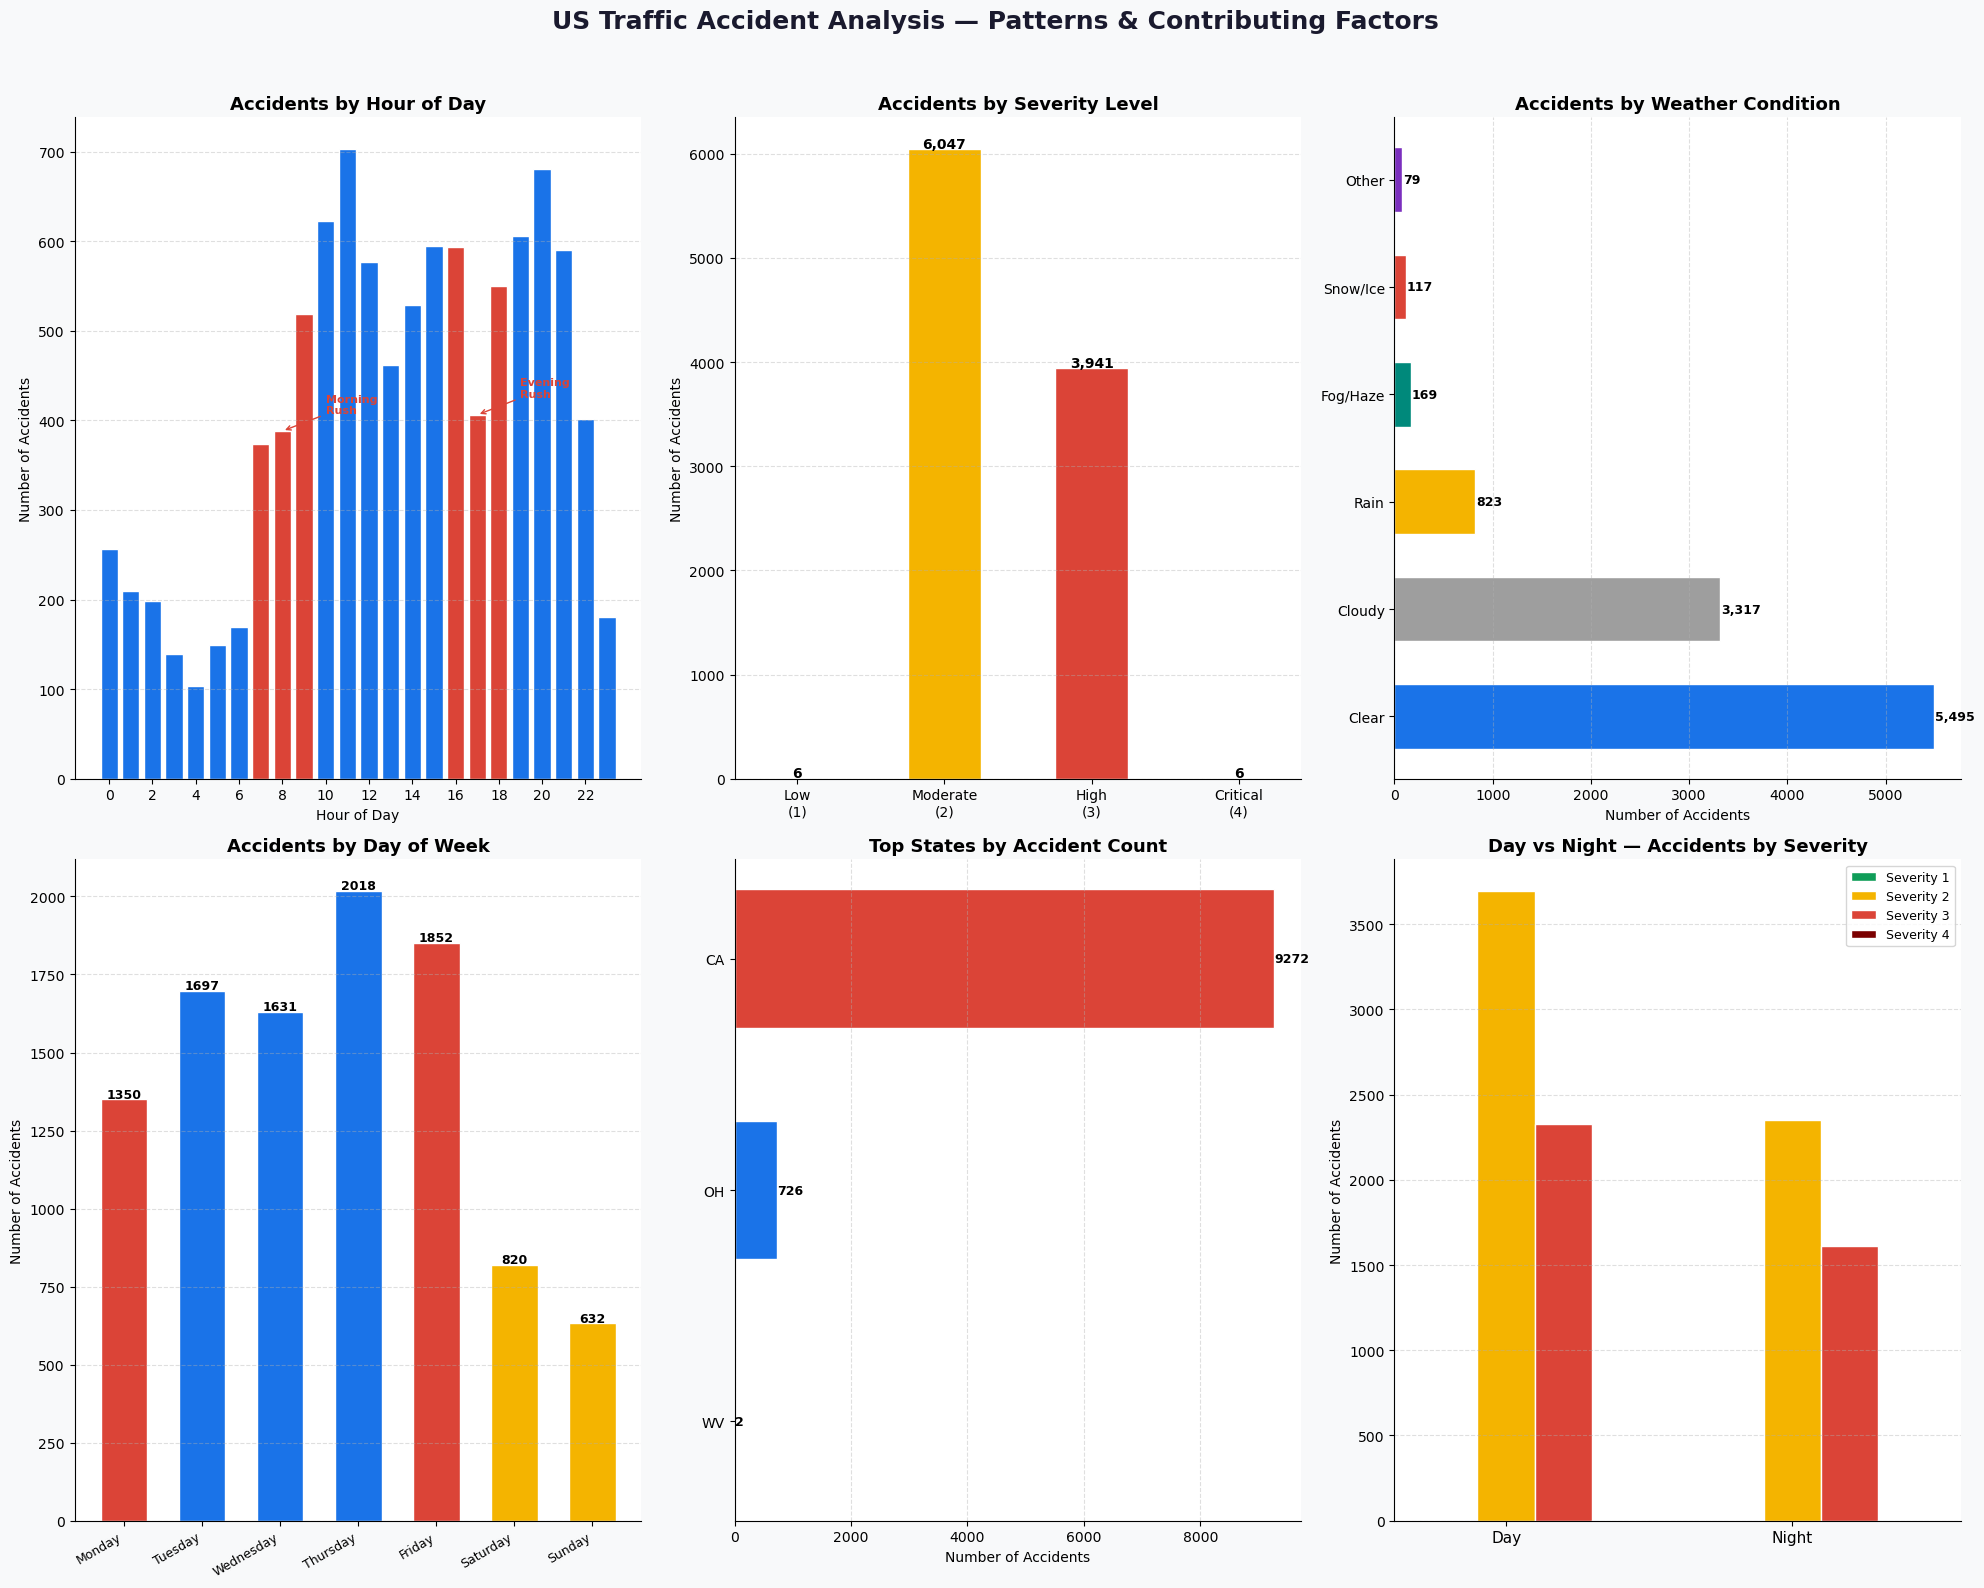

Done!


In [1]:
# ============================================================
# PRODIGY INFOTECH — Data Science Internship
# Task 05: Traffic Accident Pattern Analysis
# Dataset: US Accidents (Sobhan Moosavi) — Kaggle
# Author: Edmond Wehbe
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD DATA ─────────────────────────────────────────────
# For full dataset: change filename to 'US_Accidents_March23.csv'
file_path = r"C:\Users\Lenovo\OneDrive\Desktop\task5-prodigy\sample_US_Accidents.csv"
df = pd.read_csv(file_path)

# ── 2. FEATURE ENGINEERING ────────────────────────────────────
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['Hour']       = df['Start_Time'].dt.hour
df['Month']      = df['Start_Time'].dt.month
df['DayOfWeek']  = df['Start_Time'].dt.day_name()
df['Year']       = df['Start_Time'].dt.year

# ── 3. CLEAN ─────────────────────────────────────────────────
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')
df['Temperature(F)']    = df['Temperature(F)'].fillna(df['Temperature(F)'].median())
df['Visibility(mi)']    = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())

# ── 4. SIMPLIFY WEATHER ───────────────────────────────────────
def simplify_weather(w):
    w = str(w).lower()
    if 'rain' in w or 'drizzle' in w or 'shower' in w: return 'Rain'
    if 'snow' in w or 'sleet' in w or 'ice' in w:      return 'Snow/Ice'
    if 'fog'  in w or 'haze'  in w or 'mist'  in w:   return 'Fog/Haze'
    if 'cloud' in w or 'overcast' in w:                 return 'Cloudy'
    if 'clear' in w or 'fair'  in w:                    return 'Clear'
    if 'thunder' in w or 'storm' in w:                  return 'Thunderstorm'
    if 'wind' in w or 'breezy' in w:                    return 'Windy'
    return 'Other'

df['Weather_Simple'] = df['Weather_Condition'].apply(simplify_weather)

print(f"Total accidents : {len(df):,}")
print(f"States covered  : {df['State'].nunique()}")
print(f"Date range      : {df['Start_Time'].min()} → {df['Start_Time'].max()}")

# ── 5. COLORS ─────────────────────────────────────────────────
BLUE   = '#1A73E8'; RED    = '#DB4437'
GREEN  = '#0F9D58'; ORANGE = '#F4B400'
PURPLE = '#7B2FBE'; TEAL   = '#00897B'
SEV_COLORS = {1: GREEN, 2: ORANGE, 3: RED, 4: '#7B0000'}

# ── 6. PLOT ───────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('US Traffic Accident Analysis — Patterns & Contributing Factors',
             fontsize=18, fontweight='bold', y=0.99, color='#1A1A2E')

# Chart 1 — Accidents by hour
ax1 = fig.add_subplot(2, 3, 1)
ax1.set_facecolor('#FFFFFF')
hour_counts = df.groupby('Hour').size()
colors_h    = [RED if h in [7,8,9,16,17,18] else BLUE
               for h in hour_counts.index]
ax1.bar(hour_counts.index, hour_counts.values,
        color=colors_h, edgecolor='white', width=0.8)
ax1.set_xlabel('Hour of Day', fontsize=10)
ax1.set_ylabel('Number of Accidents', fontsize=10)
ax1.set_title('Accidents by Hour of Day', fontsize=13, fontweight='bold')
ax1.set_xticks(range(0, 24, 2))
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.annotate('Morning\nRush', xy=(8, hour_counts[8]),
             xytext=(10, hour_counts[8]+20), fontsize=8,
             color=RED, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=RED, lw=1))
ax1.annotate('Evening\nRush', xy=(17, hour_counts[17]),
             xytext=(19, hour_counts[17]+20), fontsize=8,
             color=RED, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=RED, lw=1))

# Chart 2 — Accidents by severity
ax2 = fig.add_subplot(2, 3, 2)
ax2.set_facecolor('#FFFFFF')
sev_counts = df['Severity'].value_counts().sort_index()
sev_labels = {1:'Low\n(1)', 2:'Moderate\n(2)',
              3:'High\n(3)', 4:'Critical\n(4)'}
bars2 = ax2.bar([sev_labels[s] for s in sev_counts.index],
                sev_counts.values,
                color=[SEV_COLORS[s] for s in sev_counts.index],
                edgecolor='white', width=0.5)
ax2.set_ylabel('Number of Accidents', fontsize=10)
ax2.set_title('Accidents by Severity Level', fontsize=13, fontweight='bold')
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for bar, val in zip(bars2, sev_counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
             f'{val:,}', ha='center', fontweight='bold', fontsize=10)

# Chart 3 — Accidents by weather
ax3 = fig.add_subplot(2, 3, 3)
ax3.set_facecolor('#FFFFFF')
weather_counts = df['Weather_Simple'].value_counts()
colors_w = [BLUE, '#9E9E9E', ORANGE, TEAL, RED, PURPLE, GREEN]
bars3 = ax3.barh(weather_counts.index, weather_counts.values,
                 color=colors_w[:len(weather_counts)],
                 edgecolor='white', height=0.6)
ax3.set_xlabel('Number of Accidents', fontsize=10)
ax3.set_title('Accidents by Weather Condition',
              fontsize=13, fontweight='bold')
ax3.spines[['top','right']].set_visible(False)
ax3.grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars3, weather_counts.values):
    ax3.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9, fontweight='bold')

# Chart 4 — Accidents by day of week
ax4 = fig.add_subplot(2, 3, 4)
ax4.set_facecolor('#FFFFFF')
day_order  = ['Monday','Tuesday','Wednesday',
              'Thursday','Friday','Saturday','Sunday']
day_counts = df['DayOfWeek'].value_counts().reindex(day_order)
colors_d   = [RED if d in ['Friday','Monday'] else
              ORANGE if d in ['Saturday','Sunday'] else
              BLUE for d in day_order]
ax4.bar(day_order, day_counts.values,
        color=colors_d, edgecolor='white', width=0.6)
ax4.set_ylabel('Number of Accidents', fontsize=10)
ax4.set_title('Accidents by Day of Week', fontsize=13, fontweight='bold')
ax4.set_xticklabels(day_order, rotation=30, ha='right', fontsize=9)
ax4.spines[['top','right']].set_visible(False)
ax4.grid(axis='y', linestyle='--', alpha=0.4)
for i, val in enumerate(day_counts.values):
    ax4.text(i, val+5, str(val), ha='center',
             fontsize=9, fontweight='bold')

# Chart 5 — Top 10 states
ax5 = fig.add_subplot(2, 3, 5)
ax5.set_facecolor('#FFFFFF')
state_counts = df['State'].value_counts().head(10).sort_values()
colors_st    = [RED if s == state_counts.idxmax() else BLUE
                for s in state_counts.index]
bars5 = ax5.barh(state_counts.index, state_counts.values,
                 color=colors_st, edgecolor='white', height=0.6)
ax5.set_xlabel('Number of Accidents', fontsize=10)
ax5.set_title('Top States by Accident Count',
              fontsize=13, fontweight='bold')
ax5.spines[['top','right']].set_visible(False)
ax5.grid(axis='x', linestyle='--', alpha=0.4)
for bar, val in zip(bars5, state_counts.values):
    ax5.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
             str(val), va='center', fontsize=9, fontweight='bold')

# Chart 6 — Day vs Night by severity
ax6 = fig.add_subplot(2, 3, 6)
ax6.set_facecolor('#FFFFFF')
day_night = df.groupby(
    ['Sunrise_Sunset','Severity']).size().unstack(fill_value=0)
x = np.arange(len(day_night.index))
w = 0.2
sev_palette = [GREEN, ORANGE, RED, '#7B0000']
for i, (sev, color) in enumerate(
        zip(sorted(df['Severity'].unique()), sev_palette)):
    if sev in day_night.columns:
        ax6.bar(x + i*w, day_night[sev].values, width=w,
                color=color, edgecolor='white',
                label=f'Severity {sev}')
ax6.set_xticks(x + w)
ax6.set_xticklabels(day_night.index, fontsize=11)
ax6.set_ylabel('Number of Accidents', fontsize=10)
ax6.set_title('Day vs Night — Accidents by Severity',
              fontsize=13, fontweight='bold')
ax6.legend(fontsize=9)
ax6.spines[['top','right']].set_visible(False)
ax6.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0,0,1,0.97])
plt.savefig('task05_accident_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')
plt.show()
print("Done!")